(hansen_singleton_1982)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 用广义矩方法估计欧拉方程

```{index} single: Asset Pricing; GMM Estimation
```

```{contents} Contents
:depth: 2
```

## 概述

本讲实现了 {cite:t}`hansen1982generalized` 针对非线性理性预期模型提出的广义工具变量估计量。

前一讲 {doc}`hansen_singleton_1983` 从具有 CRRA 偏好的代表性消费者问题中推导出消费欧拉方程，并在正态性假设下用最大似然法对其进行估计。

该方法需要指定消费和回报的联合分布，其有效性取决于对数正态性是否成立。

然而，正如我们在 {doc}`hansen_singleton_1983` 中所看到的，对数正态模型被数据所拒绝。

此外，在线性-二次型环境之外，均衡的闭式解通常需要对强制变量的随机性质、偏好的性质或生产技术做出很强的假设。

{cite:t}`hansen1982generalized` 提出了一种规避这一要求的估计策略。

其核心思想是，经济主体最优化问题产生的欧拉方程隐含了一组总体正交条件，这些条件依赖于可观测变量和未知的偏好参数。

通过使这些正交条件的样本对应量接近于零，就可以在不显式求解随机均衡、不指定可观测变量分布的情况下估计参数。

不过，当分布假设被正确指定时，最大似然估计量（例如 {doc}`hansen_singleton_1983` 中的 MLE）在渐近意义上会更有效率。

相对于原论文，我们每次只估计一种回报（市值加权股票回报），仅使用月度非耐用品消费（`ND`），并省略了他们的最大似然比较（表 II）和多回报系统（表 III）。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Latex
from numba import njit
from scipy import stats
from scipy.optimize import minimize
from statsmodels.sandbox.regression import gmm
from statsmodels.tsa.stattools import acf
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

我们还在下面的隐藏单元格中定义了一个辅助函数，用于将 DataFrame 显示为 LaTeX 数组

In [2]:
def display_table(df, title=None, fmt=None):
    """
    将 DataFrame 显示为 LaTeX 数组。
    """
    if fmt is None:
        fmt = {}
    formatted = df.copy()
    for col in formatted.columns:
        if col in fmt:
            formatted[col] = formatted[col].apply(
                lambda x: fmt[col].format(x) if np.isfinite(x) else str(x))
    n_cols = len(formatted.columns)
    idx_header = r"\text{" + df.index.name + "}" if df.index.name else ""
    columns = " & ".join(
        [idx_header] + [r"\text{" + c + "}" if "\\" not in c
         and "^" not in c and "_" not in c
         else c for c in formatted.columns])
    rows = r" \\".join(
        [" & ".join([str(idx)] + [str(v) for v in row])
         for idx, row in zip(formatted.index, formatted.values)])
    col_format = "r" + "c" * n_cols
    lines = [r"\begin{array}{" + col_format + "}"]
    lines.append(columns + r" \\")
    lines.append(r"\hline")
    lines.append(rows)
    lines.append(r"\end{array}")
    latex = "\n".join(lines)
    if title:
        latex = rf"\textbf{{{title}}}" + r"\\" + "\n" + latex
    display(Latex("$" + latex + "$"))

## 经济模型

我们考虑一个单一商品经济，其中有一个代表性消费者，其偏好是 CRRA 类型的，遵循 {cite:t}`hansen1982generalized` 和 {cite:t}`hansen1983stochastic`。

```{note}
下面的讨论与 {doc}`hansen_singleton_1983` 中的设定非常接近，但更加一般化，因为它允许具有不同期限的多种资产，且不假设对数正态性。
```

代表性消费者选择随机消费和投资计划，以最大化

```{math}
:label: hs82-problem

\max E_0 \sum_{t=0}^{\infty} \beta^t u(C_t)
```

其中 $C_t$ 是第 $t$ 期的消费，$\beta \in (0,1)$ 是主观贴现因子，$u(\cdot)$ 是严格凹的单期效用函数。

消费者交易 $N$ 种可能具有不同期限的资产。

设 $Q_{jt}$ 表示在日期 $t$ 末持有的资产 $j$ 的数量，$P_{jt}$ 表示其在日期 $t$ 的价格，$R_{jt}$ 表示在日期 $t - M_j$ 购买的一单位 $M_j$ 期资产在日期 $t$ 的收益。

可行的消费和投资计划必须满足一系列预算约束

```{math}
:label: hs82-budget

C_t + \sum_{j=1}^{N} P_{jt} Q_{jt} \leq \sum_{j=1}^{N} R_{jt} Q_{jt-M_j} + W_t,
```

其中 $W_t$ 是日期 $t$ 的实际劳动收入。

我们专门考虑 CRRA 偏好

```{math}
:label: hs82-crra

u(C_t) = \frac{C_t^{1-\gamma}}{1-\gamma}, \quad \gamma > 0,
```

其中 $\gamma$ 是相对风险厌恶系数。

对 {eq}`hs82-problem` 在 {eq}`hs82-budget` 约束下最大化，给出一阶必要条件（见 {cite:t}`Lucas1978`、{cite:t}`Brock1982`、{cite:t}`PrescottMehra1980` 和 {doc}`hansen_singleton_1983`）：

```{math}
:label: hs82-general-euler

P_{jt} u'(C_t) = \beta^{M_j} E_t\!\left[R_{jt+M_j} u'(C_{t+M_j})\right], \quad j = 1, \ldots, N.
```

当资产 $j$ 是一个单期股票（$M_j = 1$），其收益 $R_{jt+1} = P_{jt+1} + D_{jt+1}$，其中 $D_{jt}$ 是股息，则**总实际回报**为 $R_{t+1}^i = (P_{i,t+1}+D_{i,t+1})/P_{i,t}$。

将 CRRA 边际效用代入 {eq}`hs82-general-euler`，并将等式两边除以 $P_{jt} u'(C_t)$，得到欧拉方程

```{math}
:label: hs82-euler

E_t\!\left[\beta \left(\frac{C_{t+1}}{C_t}\right)^{-\gamma} R_{t+1}^i\right] = 1,
```

其中 $R_{t+1}^i$ 是资产 $i$ 的总实际回报。

我们定义**随机贴现因子** $M_{t+1}(\theta) = \beta (C_{t+1}/C_t)^{-\gamma}$，其参数向量为 $\theta = (\gamma, \beta)$。

在这种记法下，欧拉方程变为 $E_t[M_{t+1}(\theta) R_{t+1}^i - 1] = 0$。

正如我们已经看到并将继续看到的，方程 {eq}`hs82-euler` 是 {doc}`hansen_singleton_1983` 和本讲的核心对象。

对于每一种主体的最优性条件都适用的交易资产（内点解，无约束性投资组合限制或交易成本），它都成立。

它依赖于可观测量（消费增长和回报）以及未知的偏好参数（$\gamma$ 和 $\beta$）。

{cite:t}`hansen1982generalized` 所要解决的挑战是，如何在不指定经济环境其余部分的情况下，从 {eq}`hs82-euler` 中估计 $\theta$。

## 从条件矩到无条件矩

从 {eq}`hs82-euler` 估计 $\theta$ 的一种自然方法是指定整个经济环境，求解均衡，然后应用最大似然法。

正如我们在 {doc}`hansen_singleton_1983` 中一起做的那样，

{cite:t}`hansen1982generalized` 认为，对于大多数非线性模型而言，这是不切实际的，因为它需要对"强制变量"的随机性质和生产技术做出很强的假设。

他们的替代方案是直接处理欧拉方程对可观测矩的含义。

欧拉方程 {eq}`hs82-euler` 表明 $E_t[M_{t+1}(\theta_0) R_{t+1}^i - 1] = 0$。

设 $z_t$ 表示任何 $q$ 维向量，其中的变量位于主体的 $t$ 时刻信息集内，并且被计量经济学家观测到。

由于 $z_t$ 在日期 $t$ 已知，

$$
E\!\left[\left(M_{t+1}(\theta_0)R_{t+1}^i - 1\right) \otimes z_t\right]
= E\!\left[z_t \otimes \underbrace{E_t\!\left[M_{t+1}(\theta_0)R_{t+1}^i - 1\right]}_{=\,0\text{ 根据欧拉方程}}\right] = 0.
$$

这产生了矩约束

```{math}
:label: hs82-uncond

E\!\left[\left(M_{t+1}(\theta_0)R_{t+1}^i - 1\right) \otimes z_t\right] = 0,
```

其中 $\otimes$ 表示克罗内克积。

向量 $z_t$ 扮演**工具**的角色。

条件欧拉方程 $E_t[M_{t+1}R_{t+1}^i - 1] = 0$ 表明，给定主体 $t$ 时刻信息集中的*所有内容*，定价误差是不可预测的。

这是一个非常强的约束——它表明定价误差与每个 $t$ 时刻可测的随机变量正交。

在实践中我们无法使用整个信息集，但我们可以选取任何有限的 $t$ 时刻可观测变量集合 $z_t$，并且正交性仍然必须成立。

我们纳入 $z_t$ 中的每个变量都给我们一个样本矩条件 $\frac{1}{T}\sum_t (M_{t+1}R_{t+1}^i - 1)\, z_{kt} \approx 0$，我们可以从数据中计算它。

更多的工具意味着更多需要匹配的正交条件，这可以提高效率，并提供更多的过度识别约束来检验模型。

有 $q$ 个工具和 $m$ 个欧拉方程时，我们得到 $mq$ 个矩约束用于估计参数向量 $\theta$。

对于一个回报和 $p$ 个工具滞后，{cite:t}`hansen1982generalized` 使用

```{math}
:label: hs82-instruments

z_t = \left[1, R_t, g_t, R_{t-1}, g_{t-1}, \ldots, R_{t-p+1}, g_{t-p+1}\right]^\top,
```

其中 $g_t = C_t / C_{t-1}$ 是总消费增长。

```{note}
{cite:t}`hansen1982generalized` 将 $z_t$ 描述为"$x_{t+1}$ 的滞后值"，其中 $x_{t+1} = (R_{t+1}, g_{t+1})$。

常数 1 没有明确说明，但由他们表 I 中报告的自由度所隐含。
```

更一般地，{cite:t}`hansen1982generalized` 将一阶条件写为 $E_t[h(x_{t+n}, b_0)] = 0$，其中 $x_{t+n}$ 是日期为 $t+n$ 的可观测量向量，$b_0$ 是真实参数向量。

在单期股票的情况下，扰动 $u_{t+1} = h(x_{t+1}, b_0)$ 是序列不相关的。

通过克罗内克积堆叠矩条件给出 $f(x_{t+n}, z_t, b) = h(x_{t+n}, b) \otimes z_t$，一个维度为 $mq$ 的向量。

由此产生的无条件约束 $E[f(x_{t+n}, z_t, b_0)] = 0$ 同时嵌套了单回报单期欧拉方程和多期限资产定价约束。

正交条件和滞后工具向量遵循方程 {eq}`hs82-uncond` 和 {eq}`hs82-instruments`

In [3]:
def euler_error_horizon(params, exog, horizon=1):
    """
    在给定视界下，为 (γ, β) 计算欧拉方程定价误差。
    """
    if horizon < 1:
        raise ValueError("horizon must be at least one.")
    γ, β = params
    gross_return = exog[:, 0]
    gross_cons_growth = exog[:, 1]
    return (β ** horizon) * gross_cons_growth ** (-γ) * gross_return - 1.0


def euler_error_grad_horizon(params, exog, horizon=1):
    """
    在给定视界下，欧拉误差关于 (γ, β) 的梯度。
    """
    if horizon < 1:
        raise ValueError("horizon must be at least one.")
    γ, β = params
    gross_return = exog[:, 0]
    gross_cons_growth = exog[:, 1]

    g_pow = gross_cons_growth ** (-γ)
    common = (β ** horizon) * g_pow * gross_return

    dγ = -common * np.log(gross_cons_growth)
    dβ = horizon * (β ** (horizon - 1)) * g_pow * gross_return
    return np.column_stack([dγ, dβ])


def euler_error(params, exog):
    """
    为 (γ, β) 计算单期欧拉方程定价误差。
    """
    return euler_error_horizon(params, exog, horizon=1)

一个辅助函数为非线性 IV-GMM 对齐结果和滞后工具

In [4]:
def build_gmm_arrays(data, n_lags):
    """
    为非线性 IV-GMM 构建 endog、exog 和工具。
    """
    if n_lags < 1:
        raise ValueError("n_lags must be at least one.")
    if data.shape[0] <= n_lags:
        raise ValueError("Sample size must exceed n_lags.")

    t_obs = data.shape[0]
    exog = data[n_lags:, :]
    endog = np.zeros(exog.shape[0])
    n_obs = t_obs - n_lags
    n_instr = 2 * n_lags + 1

    instruments = np.empty((n_obs, n_instr))
    instruments[:, 0] = 1.0

    for j in range(n_lags):
        left = 2 * j + 1
        right = left + 2
        instruments[:, left:right] = data[n_lags - 1 - j : t_obs - 1 - j, :]

    return endog, exog, instruments

当资产的期限 $n > 1$ 时，欧拉方程涉及 $n$ 期复合回报和消费增长。

对于 CRRA 偏好，$n$ 期欧拉约束为

```{math}
:label: hs82-euler-n

E_t\!\left[\beta^n \left(\frac{C_{t+n}}{C_t}\right)^{-\gamma} R_{t,t+n}^i\right] = 1.
```

对于估计，$n$ 期 exog 既可以使用直接观测到的 $n$ 期回报/收益，也可以通过在 $n$ 个连续周期内复合单期回报和消费增长来构建。

同样，{cite:t}`hansen1982generalized` 的一个关键要求是，工具 $z_t$ 必须位于主体的 $t$ 时刻信息集 $\mathcal{I}_t$ 内。

对于多期情形，工具必须相对于 $\mathcal{I}_t$ 可测。

特别地，应避免使用任何仍包含 $t$ 之后周期的滞后多期总量，因为这些量会嵌入不属于 $\mathcal{I}_t$ 的实现值。

$n$ 期 exog 通过复合单期数据构建，工具的时间安排使其位于 $\mathcal{I}_t$ 内。

In [5]:
def build_gmm_arrays_horizon(one_period_data, n_lags, horizon):
    """
    为多期 GMM 构建 endog、exog 和工具。

    Exog 包含 n 期复合回报和消费增长。
    """
    if horizon < 1:
        raise ValueError("horizon must be at least one.")
    if n_lags < 1:
        raise ValueError("n_lags must be at least one.")
    T = one_period_data.shape[0]
    if T <= n_lags + horizon:
        raise ValueError("Sample size too small for given n_lags and horizon.")

    # 每个观测从索引 t 开始（窗口中的第一个周期）
    # 窗口跨越 one_period_data[t : t + horizon]
    # 工具使用 one_period_data[t - 1], ..., one_period_data[t - n_lags]
    starts = np.arange(n_lags, T - horizon + 1)
    n_obs = len(starts)

    exog = np.empty((n_obs, 2))
    n_instr = 2 * n_lags + 1
    instruments = np.empty((n_obs, n_instr))
    instruments[:, 0] = 1.0

    for i, t in enumerate(starts):
        window = one_period_data[t : t + horizon, :]
        exog[i, 0] = np.prod(window[:, 0])   # n 期回报
        exog[i, 1] = np.prod(window[:, 1])   # n 期消费增长
        for j in range(n_lags):
            instruments[
                i, 2 * j + 1 : 2 * j + 3] = one_period_data[t - 1 - j, :]

    endog = np.zeros(n_obs)
    return endog, exog, instruments

当 $n > 1$ 时，欧拉方程涉及日期为 $t + n$ 的变量，且扰动 $u_{t+n} = h(x_{t+n}, b_0)$ 通常将是序列相关的。

正如 {cite:t}`hansen1982generalized` 所指出的，如果 $m$ 种资产都是单期股票，则 $u$ 是序列不相关的，因为对 $x_{t-s}$（$s \geq 0$）的观测位于主体的 $t$ 时刻信息集内，且 $E_t[h(x_{t+1}, b_0)] = 0$。

但如果对某些资产 $j$ 有 $n_j > 1$，则条件 $E_t[h(x_{t+n}, b_0)] = 0$ 并不排除 $u$ 中的序列相关，因为当 $n > 1$ 时 $x_{t+n-1}$ 不一定在 $I_t$ 中。

长期协方差 $S_0$ 中的总体自协方差数量由 $n$ 确定，即移动平均扰动项 $u_t$ 的阶数。

我们直接将其实现为一个有限阶协方差估计器

In [6]:
def finite_ma_covariance(moment_series, ma_order):
    """
    为矩向量估计
    S = Gamma_0 + sum_{j=1}^{ma_order}(Gamma_j + Gamma_j.T)。
    """
    if ma_order < 0:
        raise ValueError("ma_order must be nonnegative.")
    if moment_series.ndim != 2:
        raise ValueError("moment_series must be 2D.")

    t_obs, n_mom = moment_series.shape
    if t_obs <= ma_order:
        raise ValueError("Need more observations than ma_order.")

    # 使用*未中心化*的交叉乘积
    # T^{-1} sum_t f_t f_{t-j}'，然后加上对称滞后项。
    s_hat = moment_series.T @ moment_series / t_obs

    for j in range(1, ma_order + 1):
        gamma_j = moment_series[j:, :].T @ moment_series[:-j, :] / t_obs
        s_hat += gamma_j + gamma_j.T

    ridge = 1e-8 * np.eye(n_mom)
    return s_hat + ridge

{cite:t}`hansen1982generalized` 中的估计程序是一个两步广义工具变量程序。

在第一步中，我们用一个次优权重矩阵（单位矩阵）最小化 GMM 准则，以获得一个一致的初步估计 $b_T$。

在第二步中，我们使用 $b_T$ 来估计样本矩条件的协方差矩阵，并对其求逆以形成最优权重矩阵，然后重新最小化准则。

让我们实现这个算法

In [7]:
def two_step_gmm(data, n_lags, ma_order=0, horizon=1, start_params=None):
    """
    使用有限阶协方差的两步 GMM。

    欧拉误差使用 β**horizon。
    """
    if start_params is None:
        start_params = np.array([1.0, 0.99])
    else:
        start_params = np.asarray(start_params, dtype=float)

    if horizon == 1:
        _, exog, instruments = build_gmm_arrays(data, n_lags)
    else:
        _, exog, instruments = build_gmm_arrays_horizon(data, n_lags, horizon)
    n_obs = exog.shape[0]

    def sample_moments(params):
        err = euler_error_horizon(params, exog, horizon=horizon)
        return err[:, None] * instruments

    def objective(params, weight_matrix):
        g_bar = sample_moments(params).mean(axis=0)
        return float(g_bar @ weight_matrix @ g_bar)

    def objective_grad(params, weight_matrix):
        g_bar = sample_moments(params).mean(axis=0)
        grad_err = euler_error_grad_horizon(params, exog, horizon=horizon)
        d_bar = (instruments.T @ grad_err) / n_obs
        return 2.0 * d_bar.T @ weight_matrix @ g_bar

    q = instruments.shape[1]
    w_identity = np.eye(q)

    bounds = [(-2.0, 10.0), (0.85, 1.5)]

    def coarse_starts(weight_matrix, n_best=5):
        γ_grid = np.linspace(bounds[0][0], bounds[0][1], 33)
        β_grid = np.linspace(bounds[1][0], bounds[1][1], 33)
        scored = []
        for γ0 in γ_grid:
            for β0 in β_grid:
                params0 = np.array([γ0, β0])
                val = objective(params0, weight_matrix)
                if np.isfinite(val):
                    scored.append((val, params0))
        scored.sort(key=lambda item: item[0])
        return [params for _, params in scored[:n_best]] or [start_params]

    def best_local_minimize(weight_matrix, starts):
        best = None
        for x0 in starts:
            res = minimize(
                objective,
                x0=x0,
                args=(weight_matrix,),
                jac=objective_grad,
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": 25_000},
            )
            if not np.isfinite(res.fun):
                continue
            if best is None or (res.fun < best.fun):
                best = res
        return best if best is not None else minimize(
            objective,
            x0=start_params,
            args=(weight_matrix,),
            jac=objective_grad,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 25_000},
        )

    step1_starts = [start_params] + coarse_starts(w_identity, n_best=5)
    step1 = best_local_minimize(w_identity, step1_starts)
    params1 = step1.x

    m1 = sample_moments(params1)
    s_hat = finite_ma_covariance(m1, ma_order=ma_order)
    w_opt = np.linalg.pinv(s_hat)

    step2_starts = [params1] + coarse_starts(w_opt, n_best=5)
    step2 = best_local_minimize(w_opt, step2_starts)
    params2 = step2.x

    m2 = sample_moments(params2)
    s_hat2 = finite_ma_covariance(m2, ma_order=ma_order)
    w_opt2 = np.linalg.pinv(s_hat2)
    g2 = m2.mean(axis=0)
    j_stat = float(n_obs * (g2 @ w_opt2 @ g2))
    df = instruments.shape[1] - len(params2)
    j_prob = float(stats.chi2.cdf(j_stat, df=df)) if df > 0 else np.nan
    p_value = float(1.0 - j_prob) if df > 0 else np.nan

    # 最优权重下的渐近协方差： (D' S^{-1} D)^{-1} / T。
    grad_err = euler_error_grad_horizon(params2, exog, horizon=horizon)
    d_hat = (instruments.T @ grad_err) / n_obs
    cov_hat = np.linalg.pinv(d_hat.T @ w_opt2 @ d_hat) / n_obs
    se_hat = np.sqrt(np.diag(cov_hat))

    return {
        "params_step1": params1,
        "params_step2": params2,
        "se_step2": se_hat,
        "weight_opt": w_opt2,
        "j_stat": j_stat,
        "j_df": int(df),
        "j_prob": j_prob,
        "j_pval": p_value,
        "n_obs": int(n_obs),
        "success": bool(step2.success),
    }

## GMM 准则与渐近理论

我们现在将估计程序形式化。

设 $m_t(\theta) = (M_{t+1}(\theta) R_{t+1}^i - 1) \otimes z_t$ 表示日期 $t$ 处的矩条件向量，并定义样本均值

```{math}
:label: hs82-sample-moments

g_T(\theta) = \frac{1}{T} \sum_{t=1}^T m_t(\theta).
```

如果模型被正确指定，对于较大的 $T$，$g_T(\theta_0)$ 应接近于零。

我们通过选择使 $g_T$ 尽可能接近零的参数向量来估计 $\theta$，其接近程度由一个二次型度量：

```{math}
:label: hs82-criterion

\hat\theta = \arg\min_\theta g_T(\theta)^\top W_T g_T(\theta)
```

其中 $W_T$ 是一个对称正定权重矩阵。

在 {cite:t}`Hansen1982` 给出的正则条件下，GMM 估计量是一致的、渐近正态的，并具有三明治协方差矩阵

```{math}
:label: hs82-asymptotic

\sqrt{T}(\hat\theta-\theta_0) \Rightarrow N\!\left(0, (D^\top W D)^{-1} D^\top W S W D (D^\top W D)^{-1}\right),
```

其中 $D = E[\partial m_t(\theta_0)/\partial\theta^\top]$ 是矩条件的雅可比矩阵，$S$ 是 $m_t(\theta_0)$ 的长期协方差矩阵，$W$ 是 $W_T$ 的概率极限。

{cite:t}`Hansen1982` 表明，最优权重矩阵是 $W^* = S^{-1}$，它在所有 $W$ 的选择中产生最小的渐近协方差矩阵。

在 $W = S^{-1}$ 下，三明治简化为 $(D^\top S^{-1} D)^{-1}$。

当矩条件的数量 $r$（例如，对于 $m$ 个欧拉方程和 $q$ 个工具，$r = mq$）超过参数数量 $k$ 时，模型是过度识别的，我们可以检验数据是否与所维持的约束一致。

{cite:t}`hansen1982generalized` 使用 {cite:t}`Hansen1982` 的一个结果来检验过度识别约束：

```{math}
:label: hs82-jtest

J_T = T\, g_T(\hat\theta)^\top \hat S^{-1} g_T(\hat\theta) \Rightarrow \chi^2_{r-k},
```

其中 $\hat S$ 是 $S$ 的一致估计量。

相对于 $\chi^2_{r-k}$ 临界值较大的 $J_T$ 导致拒绝模型的过度识别约束。

对于多期情形（$n > 1$），如上所述，扰动至多为 MA($n-1$)，因此 {cite:t}`hansen1982generalized` 通过设置 $W_0 = S_0^{-1}$ 获得最优权重矩阵，其中

```{math}
:label: hs82-finite-so

S_0 = \sum_{j=-n+1}^{n-1} E\!\left[f(x_{t+n}, z_t, b_0)\, f(x_{t+n-j}, z_{t-j}, b_0)^\top\right].
```

## 协方差估计与工具的选择

对于单期欧拉方程（$n = 1$），扰动 $u_{t+1} = M_{t+1}(\theta_0) R_{t+1} - 1$ 是一个鞅差分序列。

在这种情况下，矩向量 $m_t(\theta_0) = u_{t+1} \otimes z_t$ 是序列不相关的，长期协方差 $S$ 等于同期方差 $E[m_t m_t^\top]$。

因此，协方差估计器不需要核或带宽的选择。

我们只需使用样本类比 $\hat S = T^{-1} \sum_t m_t m_t^\top$。

在下面的实现中，我们使用 HAC（异方差和自相关一致）估计器，以应对时间聚合或测量时序可能产生的轻微序列依赖。

这是一个现代的预防措施，不属于原始 {cite:t}`hansen1982generalized` 程序的一部分，后者直接利用已知的 MA 阶数，如 {eq}`hs82-finite-so` 所示。

工具滞后数 $p$ 决定了我们使用多少正交条件，从而决定了 $J$ 检验的功效。

{cite:t}`hansen1982generalized` 报告了 NLAG $= 1, 2, 4, 6$ 的结果，并指出（脚注 12）使用更多的正交条件可能导致估计量具有不太理想的小样本性质。

下面我们实现估计程序，允许用户选择滞后数以及是否对协方差矩阵使用 HAC 估计器

In [8]:
def estimate_gmm(
    data,
    n_lags,
    start_params=None,
    use_hac=True,
    hac_maxlag=None,
    maxiter=2,
):
    """
    使用非线性 IV-GMM 估计欧拉方程参数。
    """
    if start_params is None:
        start_params = np.array([1.0, 0.99])

    endog, exog, instruments = build_gmm_arrays(data, n_lags)
    model = gmm.NonlinearIVGMM(endog, exog, instruments, euler_error)

    if use_hac:
        if hac_maxlag is None:
            hac_maxlag = max(
                1, int(
                    np.floor(4.0 * (endog.shape[0] / 100.0) ** (2.0 / 9.0))))
        result = model.fit(
            start_params=start_params,
            maxiter=maxiter,
            optim_method="bfgs",
            optim_args={"disp": False},
            weights_method="hac",
            wargs={"maxlag": hac_maxlag},
        )
    else:
        result = model.fit(
            start_params=start_params,
            maxiter=maxiter,
            optim_method="bfgs",
            optim_args={"disp": False},
        )

    return result

接下来，我们包含一个辅助函数，用于跨滞后长度运行 GMM 估计并在表中汇总结果

In [9]:
def run_gmm_by_lag(
    data,
    lags=(1, 2, 4, 6),
    use_hac=True,
    hac_maxlag=None,
):
    """
    按滞后长度估计 GMM 模型并返回汇总表。
    """
    rows = []
    results = {}

    for lag in lags:
        res = estimate_gmm(data, n_lags=lag, use_hac=use_hac, hac_maxlag=hac_maxlag)
        results[lag] = res
        j_stat, j_pval, j_df = res.jtest()
        j_prob = float(stats.chi2.cdf(j_stat, df=j_df)) if j_df > 0 else np.nan
        rows.append(
            {
                "NLAG": lag,
                "γ_hat": res.params[0],
                "se_γ": res.bse[0],
                "β_hat": res.params[1],
                "se_β": res.bse[1],
                "j_stat": j_stat,
                "j_prob": j_prob,
                "j_pval": j_pval,
                "j_df": int(j_df),
                "n_obs": int(res.nobs),
            }
        )

    table = pd.DataFrame(rows).set_index("NLAG")
    return table, results


def run_two_step_by_lag(
    data,
    lags=(1, 2, 4, 6),
    horizon=1,
):
    """
    跨滞后长度、使用精确 S0（MA 阶数 0）的两步 GMM。
    """
    rows = []
    start_params = None
    for lag in lags:
        res = two_step_gmm(
            data,
            n_lags=lag,
            ma_order=0,
            horizon=horizon,
            start_params=start_params,
        )
        start_params = res["params_step2"]
        rows.append(
            {
                "NLAG": lag,
                "γ_hat": res["params_step2"][0],
                "se_γ": res["se_step2"][0],
                "β_hat": res["params_step2"][1],
                "se_β": res["se_step2"][1],
                "j_stat": res["j_stat"],
                "j_prob": res["j_prob"],
                "j_pval": res["j_pval"],
                "j_df": res["j_df"],
                "n_obs": res["n_obs"],
            }
        )
    return pd.DataFrame(rows).set_index("NLAG")

### 模拟

在将估计量应用于真实数据之前，我们验证 GMM 能从模拟数据中恢复已知参数。

我们构建一个模拟器，生成按构造满足欧拉方程的合成回报-增长对。

我们从平稳的 AR(1) 生成对数消费增长，在已知的真实参数下计算随机贴现因子，并将总回报构造为
$R_{t+1} = \xi_{t+1} / M_{t+1}(\theta_0)$，其中 $\xi_{t+1}$ 是均值为一的独立同分布对数正态冲击。

In [10]:
@njit
def _ar1_simulate(mu_c, phi_c, sigma_c, shocks_c, total_n):
    """
    模拟 AR(1) 对数消费增长。
    """
    delta_c = np.empty(total_n)
    delta_c[0] = mu_c
    for t in range(1, total_n):
        delta_c[t] = mu_c * (1.0 - phi_c) + phi_c * delta_c[t - 1] + sigma_c * shocks_c[t]
    return delta_c


def simulate_euler_sample(
    n_obs,
    γ_true=0.8,
    β_true=0.993,
    seed=0,
):
    """
    模拟 [总实际回报, 总消费增长]。
    """
    rng = np.random.default_rng(seed)
    mu_c = 0.0015
    sigma_c = 0.006
    phi_c = 0.4
    sigma_eta = 0.02
    burn_in = 200

    total_n = n_obs + burn_in
    shocks_c = rng.standard_normal(total_n)
    delta_c = _ar1_simulate(mu_c, phi_c, sigma_c, shocks_c, total_n)

    cons_growth = np.exp(delta_c[burn_in:])
    sdf = β_true * cons_growth ** (-γ_true)

    # 正的均值为一的回报冲击： E[ξ]=1，因此按构造 E[M R]=1。
    eps = rng.standard_normal(n_obs)
    xi = np.exp(sigma_eta * eps - 0.5 * sigma_eta**2)
    gross_return = xi / sdf

    return np.column_stack([gross_return, cons_growth])

我们设定 $\gamma = 2$ 和 $\beta = 0.995$ 作为真实参数，并从欧拉一致的数据生成过程生成 700 个月度观测值。

In [11]:
γ_true = 2.0
β_true = 0.995
sim_data = simulate_euler_sample(
    n_obs=5000,
    γ_true=γ_true,
    β_true=β_true,
    seed=0,
)

print(f"Simulation sample size: {sim_data.shape[0]}")
print(f"True γ: {γ_true:.3f}")
print(f"True β: {β_true:.3f}")

Simulation sample size: 5000
True γ: 2.000
True β: 0.995


我们现在跨滞后长度估计 GMM，遵循 {cite:t}`hansen1982generalized` 中表 I 的格式。

In [12]:
sim_table = run_two_step_by_lag(sim_data, lags=(1, 2, 4, 6), horizon=1)

In [13]:
sim_pretty = sim_table[
    ["γ_hat", "se_γ", "β_hat", "se_β", "j_stat", "j_df", "j_prob"]].rename(
    columns={
        "γ_hat": r"\hat{\gamma}",
        "se_γ": r"\mathrm{se}(\hat{\gamma})",
        "β_hat": r"\hat{\beta}",
        "se_β": r"\mathrm{se}(\hat{\beta})",
        "j_stat": "J",
        "j_df": "df",
        "j_prob": "Prob(J)",
    }
)
display_table(
    sim_pretty,
    fmt={
        r"\hat{\gamma}": "{:.4f}",
        r"\mathrm{se}(\hat{\gamma})": "{:.4f}",
        r"\hat{\beta}": "{:.4f}",
        r"\mathrm{se}(\hat{\beta})": "{:.4f}",
        "J": "{:.3f}",
        "Prob(J)": "{:.3f}",
        "df": "{:.0f}",
    },
)

<IPython.core.display.Latex object>

GMM 在各种滞后设定下相当接近地恢复了真实的 $\gamma$ 和 $\beta$。

对于假设检验，右尾 $p$ 值为 $1-\mathrm{Prob}(J)$。

两篇论文的表格中都可见的较大标准误表明，偏好参数 $\gamma$ 和 $\beta$ 可能是弱识别的。

为了将这一点可视化，我们使用模拟数据在 $(\gamma, \beta)$ 网格上绘制 GMM 准则

In [14]:
def gmm_objective_surface(
    data,
    n_lags=2,
    γ_grid=None,
    β_grid=None,
):
    """
    在参数网格上计算单位矩阵加权的 GMM 目标。
    """
    _, exog, instruments = build_gmm_arrays(data, n_lags)

    if γ_grid is None:
        γ_grid = np.linspace(-1.0, 8.0, 70)
    if β_grid is None:
        β_grid = np.linspace(0.96, 1.02, 70)

    objective = np.empty((len(β_grid), len(γ_grid)))

    for i, β_val in enumerate(β_grid):
        for j, γ_val in enumerate(γ_grid):
            err = euler_error(np.array([γ_val, β_val]), exog)
            moments = (err[:, None] * instruments).mean(axis=0)
            objective[i, j] = moments @ moments

    return γ_grid, β_grid, objective

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


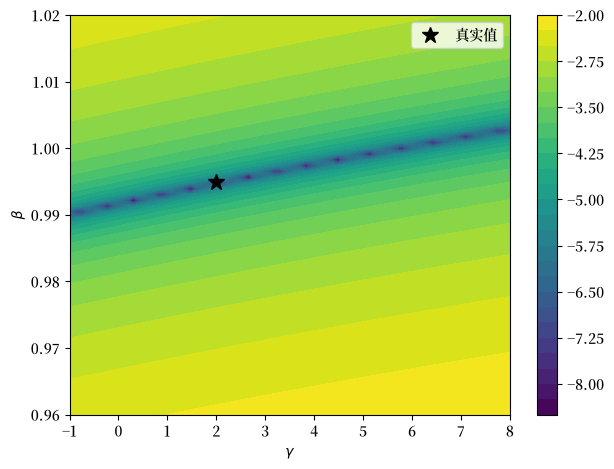

In [15]:
γ_grid, β_grid, objective = gmm_objective_surface(sim_data, n_lags=2)
log_obj = np.log10(objective + 1e-12)

fig, ax = plt.subplots()
contours = ax.contourf(γ_grid, β_grid, log_obj, levels=30, cmap="viridis")
ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$\beta$")
ax.plot(γ_true, β_true, "k*", ms=12, lw=2, label="真实值")
ax.legend()
plt.colorbar(contours, ax=ax)
plt.tight_layout()
plt.show()

准则曲面可能有拉长的谷地，其中许多参数组合几乎同样好地拟合了矩。

为了说明 {cite:t}`hansen1982generalized` 第 2 节中的多期情形，我们使用重叠视界的回报和消费增长估计三期欧拉约束，工具由日期为 $t$ 或更早的单期数据构成，并采用适合 MA(2) 扰动的有限阶协方差。

In [16]:
horizon_n = 3
two_step = two_step_gmm(
    sim_data,
    n_lags=2,
    ma_order=horizon_n - 1,
    horizon=horizon_n,
)

print(f"Horizon n: {horizon_n}")
print(f"Step-2 converged: {two_step['success']}")
print(f"Step-2 gamma: {two_step['params_step2'][0]:.4f}")
print(f"Step-2 beta (one-period): {two_step['params_step2'][1]:.4f}")
print(
    f"J({two_step['j_df']}): {two_step['j_stat']:.3f}, "
    f"Prob={two_step['j_prob']:.3f}, p={two_step['j_pval']:.3f}"
)

_, exog_n, _ = build_gmm_arrays_horizon(sim_data, n_lags=2, horizon=horizon_n)
acf_n = acf(
    euler_error_horizon(two_step["params_step2"], exog_n, horizon=horizon_n),
    nlags=6,
    fft=True,
)
print("Euler-error ACF lags 1-3:", ", ".join([f"{v:.3f}" for v in acf_n[1:4]]))

Horizon n: 3
Step-2 converged: True
Step-2 gamma: 2.1095
Step-2 beta (one-period): 0.9949
J(3): 2.518, Prob=0.528, p=0.472
Euler-error ACF lags 1-3: 0.678, 0.356, 0.023


低滞后 ACF 与 3 期视界所隐含的 MA(2) 依赖性一致。

我们现在运行一个具有 500 次重复的蒙特卡洛练习，以可视化 $\hat\gamma$、$\hat\beta$ 和 $J$ 统计量的有限样本分布，并验证 {cite:t}`hansen1982generalized` 第 3 节的渐近理论提供了合理的近似。

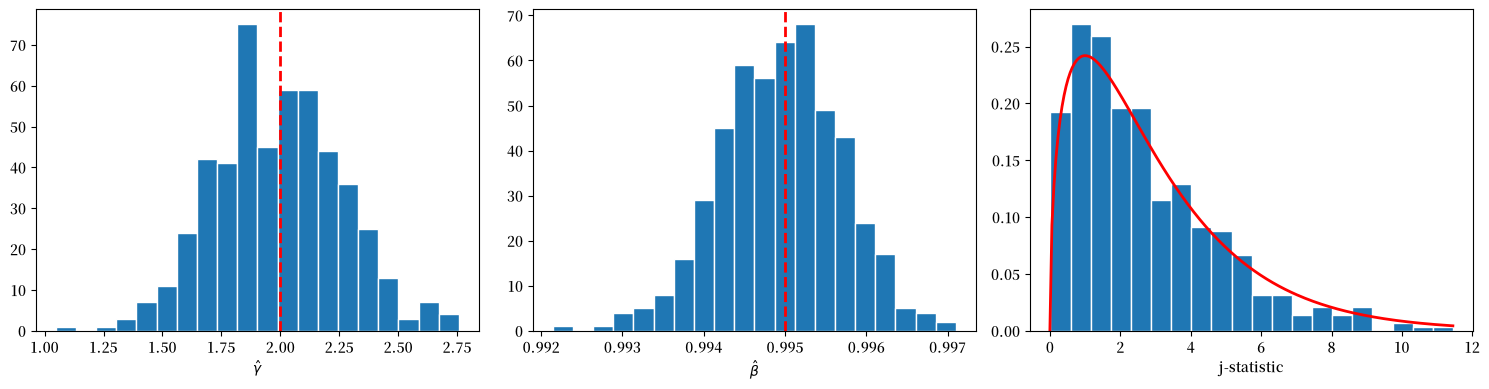

In [17]:
n_rep = 500
estimates = []
j_stats = []

for rep in range(n_rep):
    rep_data = simulate_euler_sample(
        n_obs=900,
        γ_true=γ_true,
        β_true=β_true,
        seed=rep,
    )
    rep_res = estimate_gmm(rep_data, n_lags=2, use_hac=True, maxiter=2)
    estimates.append(rep_res.params)
    j_stats.append(rep_res.jval)

estimates = np.asarray(estimates)
j_stats = np.asarray(j_stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(estimates[:, 0], bins=20, edgecolor="white")
axes[0].axvline(γ_true, color="red", ls="--", lw=2)
axes[0].set_xlabel(r"$\hat{\gamma}$")
axes[1].hist(estimates[:, 1], bins=20, edgecolor="white")
axes[1].axvline(β_true, color="red", ls="--", lw=2)
axes[1].set_xlabel(r"$\hat{\beta}$")

df_j = 2 * 2 + 1 - 2
axes[2].hist(j_stats, bins=20, density=True, edgecolor="white")
grid = np.linspace(0.0, max(j_stats.max(), 1.0), 200)
axes[2].plot(grid, stats.chi2.pdf(grid, df_j), "r-", lw=2)
axes[2].set_xlabel("j-statistic")
plt.tight_layout()
plt.show()

$\hat\gamma$ 和 $\hat\beta$ 都以其真实值为中心，$J$ 直方图跟踪了 $\chi^2$ 密度，支持了在此样本量下的渐近近似。

## 经验 GMM 估计

我们现在将 GMM 应用于观测数据，遵循 {cite:t}`hansen1982generalized` 第 5 节的经验策略。

{cite:t}`hansen1982generalized` 使用月度人均非耐用品消费（ND）和非耐用品加服务（NDS），并与来自 CRSP 的等权重（EWR）和市值加权（VWR）总股票回报配对，时间跨度为 1959:2 至 1978:12。

我们专注于他们的 ND+VWR 设定，使用 FRED 非耐用品消费和 Ken French 市值加权市场回报作为 CRSP 的代理，采用相同的 1959:2--1978:12 样本期。

由于 Ken French 回报与原始的 CRSP 纽约证券交易所市值加权回报不完全相同，我们只想在定性上与论文匹配。

本讲和配套讲座 {doc}`hansen_singleton_1983` 使用相同的数据构建。

下面的隐藏单元格从 [QuantEcon/data-lectures](https://github.com/QuantEcon/data-lectures) 加载了一个月度数据集，包含总实际回报和总消费增长。这些数据由维护脚本 [`builders/hansen_singleton_1982_data.py`](https://github.com/QuantEcon/data-lectures/blob/main/builders/hansen_singleton_1982_data.py) 从 [FRED](https://fred.stlouisfed.org/) 和 [Ken French](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html) 数据库构建，并在此直接从 GitHub 读取。

In [18]:
DATA_URL = "https://github.com/QuantEcon/data-lectures/raw/main/lectures/hansen_singleton_1982_data.csv"

# 一次性获取快照；load_hs_monthly_data 只对其切片。
_data = pd.read_csv(DATA_URL, index_col=0, parse_dates=True)


def load_hs_monthly_data(start="1959-02-01", end="1978-12-01"):
    """
    加载月度总实际回报和总消费增长序列。

    数据是由 QuantEcon/data-lectures 中的维护脚本
    ``builders/hansen_singleton_1982_data.py`` 构建的快照，
    该脚本从 FRED 和 Ken French 数据库构建它们。
    """
    start = pd.Timestamp(start).to_period("M").to_timestamp("M")
    end = pd.Timestamp(end).to_period("M").to_timestamp("M")
    return _data.loc[start:end].copy()


def get_estimation_data(
    start="1959-02-01",
    end="1978-12-01",
):
    """
    使用观测数据返回 (dataframe, array)。
    """
    frame = load_hs_monthly_data(start=start, end=end)
    data = frame[["gross_real_return", "gross_cons_growth"]].to_numpy()
    return frame, data

我们首先检查原始数据的矩。

In [19]:
LAGS = (1, 2, 4, 6)

emp_frame, emp_data = get_estimation_data()

print(f"Mean net real return: {(emp_data[:, 0].mean() - 1.0) * 100:.3f}%")
print(f"Std net real return: {emp_data[:, 0].std() * 100:.3f}%")
print(f"Mean net consumption growth: {(emp_data[:, 1].mean() - 1.0) * 100:.3f}%")
print(f"Std net consumption growth: {emp_data[:, 1].std() * 100:.3f}%")
print(f"Std log consumption growth: {np.log(emp_data[:, 1]).std() * 100:.3f}%")

Mean net real return: 0.308%
Std net real return: 4.335%
Mean net consumption growth: 0.093%
Std net consumption growth: 0.915%
Std log consumption growth: 0.915%


这些数据的一个特征是回报的波动率与消费增长的波动率之间存在巨大差距。

这再次是 {cite:t}`MehraPrescott1985` 股权溢价之谜背后的一个经验事实：用 CRRA 偏好匹配观测到的股权溢价需要难以置信的高风险厌恶。

我们现在使用 {cite:t}`hansen1982generalized` 中的两步广义工具变量（GIV）/ GMM 程序来估计欧拉方程。

对于单期股票回报欧拉方程（$n=1$），扰动是一个鞅差分序列，因此最优权重矩阵使用同期协方差 $S_0 = E[m_t m_t^\top]$。

为了匹配表 I，我们报告论文在
$E_t[\beta (C_{t+1}/C_t)^\alpha R_{t+1} - 1] = 0$ 中的指数参数 $\alpha$。

按滞后长度得到的 $\hat{\alpha}$ 和 $\hat{\beta}$ 的两步 GMM 估计为

In [20]:
gmm_raw = run_two_step_by_lag(emp_data, lags=LAGS, horizon=1)
gmm_raw.index.name = "NLAG"

table_i = pd.DataFrame(index=gmm_raw.index)
table_i.index.name = "NLAG"
table_i[r"\hat{\alpha}"] = -gmm_raw["γ_hat"]
table_i[r"SE(\hat{\alpha})"] = gmm_raw["se_γ"]
table_i[r"\beta"] = gmm_raw["β_hat"]
table_i[r"\mathrm{SE}(\beta)"] = gmm_raw["se_β"]
table_i[r"\chi^2"] = gmm_raw["j_stat"]
table_i["DF"] = gmm_raw["j_df"]
table_i["Prob"] = gmm_raw["j_prob"]

display_table(
    table_i,
    fmt={
        r"\hat{\alpha}": "{:.4f}",
        r"SE(\hat{\alpha})": "{:.4f}",
        r"\beta": "{:.4f}",
        r"\mathrm{SE}(\beta)": "{:.4f}",
        r"\chi^2": "{:.4f}",
        "DF": "{:.0f}",
        "Prob": "{:.4f}",
    },
)

<IPython.core.display.Latex object>

作为比较，{cite:t}`hansen1982generalized` 的表 I（如 [1984 年 *Econometrica* 勘误](https://www.jstor.org/stable/1911486?seq=2) 中所更正的）报告了 1959:2--1978:12 期间以下 ND+VWR 值：

In [21]:
table_i_paper = pd.DataFrame(
    {
        r"\alpha": [-1.2028, -0.5761, -0.6565, -0.9638],
        r"SE(\alpha)": [0.7789, 0.7067, 0.6896, 0.6425],
        r"\beta": [0.9976, 0.9975, 0.9978, 0.9985],
        r"\mathrm{SE}(\beta)": [0.0027, 0.0027, 0.0027, 0.0027],
        r"\chi^2": [1.457, 5.819, 7.923, 10.522],
        "DF": [1, 3, 7, 11],
        "Prob": [0.7726, 0.8792, 0.6606, 0.5159],
    },
    index=pd.Index([1, 2, 4, 6], name="NLAG"),
)

display_table(
    table_i_paper,
    fmt={
        r"\alpha": "{:.4f}",
        r"SE(\alpha)": "{:.4f}",
        r"\beta": "{:.4f}",
        r"\mathrm{SE}(\beta)": "{:.4f}",
        r"\chi^2": "{:.4f}",
        "DF": "{:.0f}",
        "Prob": "{:.4f}",
    },
)

<IPython.core.display.Latex object>

它们与我们的估计非常接近。

## 小结

GMM 估计量只需要欧拉方程隐含的正交条件和一组条件变量。

它不需要关于消费和回报的联合分布、生产技术，或除代表性主体一阶条件之外的经济环境任何其他部分的假设。

因此，GMM 提供了一种估计某些感兴趣对象的方法，而无需估计 {cite:t}`hansen1983stochastic` 在其消费增长和回报的对数线性模型中估计的所有参数。

  * 如果 {cite:t}`hansen1983stochastic` 的完整模型被正确指定，那么他们的最大似然估计量有望比本讲中描述的 GMM 估计量更有效率。
  * 估计*某物*而非估计*一切*的主题贯穿了 Lars Peter Hansen 的大部分工作。参见 {cite:t}`hansen2014nobel`